# Investor Readiness Prediction - End-to-End ML Pipeline

This notebook is the complete ML training workflow for InvestorBridge AI.

The goal is to predict an **Investor Readiness Score** from founder pitch/session signals. The final trained artifact is loaded by the FastAPI backend and used in the existing final readiness report flow.

**Why synthetic data?** This is a hackathon prototype. Real historical investor outcome data is not available yet, so this notebook creates realistic synthetic founder-session data with explainable relationships.


## 1. Setup

We load the ML stack, define artifact paths, and import the shared backend feature list. Keeping the feature list in backend code prevents training and inference from drifting apart.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "backend" / "ml" / "feature_engineering.py").exists():
            return candidate
    raise RuntimeError("Could not find project root. Open this notebook inside the repo.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
BACKEND_DIR = PROJECT_ROOT / "backend"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts"
DATA_PATH = ARTIFACTS_DIR / "synthetic_pitch_data.csv"
MODEL_PATH = ARTIFACTS_DIR / "investor_readiness_model.joblib"
FEATURE_COLUMNS_PATH = ARTIFACTS_DIR / "feature_columns.json"
METRICS_PATH = ARTIFACTS_DIR / "model_metrics.json"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.ml.feature_engineering import get_feature_columns

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print(f"Project root: {PROJECT_ROOT}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")


Project root: C:\Users\user\Desktop\Immigrant-Hackathon-NYC
Artifacts directory: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts


## 2. Generate Synthetic Pitch Session Data

The synthetic target is intentionally realistic:

- readiness increases with validation, clarity, market need, founder-market fit, business potential, confidence, Q&A quality, business model, revenue model, and go-to-market readiness;
- readiness decreases when filler words are high, speaking pace is too slow/fast, pitch length is too short, problem clarity is weak, or market need is weak;
- controlled noise is added so the model must learn patterns rather than memorize a formula.


In [2]:
def clip_100(values: np.ndarray) -> np.ndarray:
    return np.clip(values, 0, 100)


def bernoulli_from_score(rng: np.random.Generator, score: np.ndarray, shift: float) -> np.ndarray:
    probability = 1 / (1 + np.exp(-((score - 62) / 13 + shift)))
    return rng.binomial(1, probability)


def generate_synthetic_pitch_data(rows: int = 5000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    founder_quality = np.clip(rng.normal(68, 17, rows), 0, 100)
    market_quality = np.clip(rng.normal(66, 18, rows), 0, 100)
    delivery_quality = np.clip(rng.normal(70, 15, rows), 0, 100)

    problem_clarity_score = clip_100(0.62 * founder_quality + 0.38 * market_quality + rng.normal(0, 10, rows))
    market_need_score = clip_100(0.78 * market_quality + rng.normal(0, 12, rows))
    founder_market_fit_score = clip_100(0.76 * founder_quality + rng.normal(0, 12, rows))
    ai_fit_score = clip_100(0.54 * founder_quality + 0.28 * market_quality + rng.normal(10, 14, rows))
    business_potential_score = clip_100(0.48 * market_quality + 0.34 * founder_quality + rng.normal(7, 12, rows))
    validation_score = clip_100(
        0.26 * problem_clarity_score
        + 0.24 * market_need_score
        + 0.20 * founder_market_fit_score
        + 0.16 * business_potential_score
        + 0.08 * ai_fit_score
        + rng.normal(0, 6, rows)
    )

    confidence = clip_100(0.72 * delivery_quality + 0.18 * founder_quality + rng.normal(4, 10, rows))
    eye_contact = clip_100(0.82 * delivery_quality + rng.normal(5, 11, rows))
    clarity = clip_100(0.64 * delivery_quality + 0.24 * problem_clarity_score + rng.normal(0, 9, rows))
    energy = clip_100(0.78 * delivery_quality + rng.normal(8, 11, rows))
    qna_quality_score = clip_100(0.38 * validation_score + 0.32 * confidence + 0.20 * clarity + rng.normal(4, 10, rows))

    speaking_speed = np.clip(rng.normal(140 + (confidence - 72) * 0.14, 18, rows), 90, 190).round()
    filler_lambda = np.clip(18 - clarity * 0.13 - confidence * 0.05 + rng.normal(0, 2, rows), 1, 26)
    filler_words = np.clip(rng.poisson(filler_lambda), 0, 40)

    has_clear_customer = bernoulli_from_score(rng, market_need_score, -0.4)
    has_business_model = bernoulli_from_score(rng, business_potential_score, -1.0)
    has_competition_awareness = bernoulli_from_score(rng, market_need_score, -0.7)
    has_go_to_market = bernoulli_from_score(rng, business_potential_score, -0.9)
    has_revenue_model = bernoulli_from_score(rng, business_potential_score, -1.1)

    pitch_length_words = np.clip(
        rng.normal(
            210
            + has_clear_customer * 25
            + has_business_model * 35
            + has_go_to_market * 25
            + (problem_clarity_score - 70) * 0.6,
            64,
            rows,
        ),
        80,
        500,
    ).round()

    speed_penalty = np.maximum(np.abs(speaking_speed - 140) - 25, 0) * 0.28
    filler_penalty = np.minimum(filler_words * 0.48, 14)
    short_pitch_penalty = np.maximum(150 - pitch_length_words, 0) * 0.08
    long_pitch_penalty = np.maximum(pitch_length_words - 430, 0) * 0.03
    weak_problem_penalty = np.maximum(55 - problem_clarity_score, 0) * 0.16
    weak_market_penalty = np.maximum(55 - market_need_score, 0) * 0.18

    investor_readiness_score = clip_100(
        0.14 * validation_score
        + 0.12 * problem_clarity_score
        + 0.12 * market_need_score
        + 0.10 * founder_market_fit_score
        + 0.10 * business_potential_score
        + 0.08 * confidence
        + 0.08 * clarity
        + 0.10 * qna_quality_score
        + 0.03 * ai_fit_score
        + 0.03 * eye_contact
        + 0.02 * energy
        + has_business_model * 4.5
        + has_revenue_model * 4.5
        + has_go_to_market * 3.5
        + has_clear_customer * 2.5
        + has_competition_awareness * 1.5
        - speed_penalty
        - filler_penalty
        - short_pitch_penalty
        - long_pitch_penalty
        - weak_problem_penalty
        - weak_market_penalty
        + rng.normal(0, 4.8, rows)
    )

    data = pd.DataFrame(
        {
            "problem_clarity_score": problem_clarity_score.round(2),
            "market_need_score": market_need_score.round(2),
            "founder_market_fit_score": founder_market_fit_score.round(2),
            "ai_fit_score": ai_fit_score.round(2),
            "business_potential_score": business_potential_score.round(2),
            "validation_score": validation_score.round(2),
            "confidence": confidence.round(2),
            "eye_contact": eye_contact.round(2),
            "speaking_speed": speaking_speed.astype(int),
            "filler_words": filler_words.astype(int),
            "clarity": clarity.round(2),
            "energy": energy.round(2),
            "qna_quality_score": qna_quality_score.round(2),
            "pitch_length_words": pitch_length_words.astype(int),
            "has_clear_customer": has_clear_customer.astype(int),
            "has_business_model": has_business_model.astype(int),
            "has_competition_awareness": has_competition_awareness.astype(int),
            "has_go_to_market": has_go_to_market.astype(int),
            "has_revenue_model": has_revenue_model.astype(int),
            "investor_readiness_score": investor_readiness_score.round(2),
        }
    )
    return data[get_feature_columns() + ["investor_readiness_score"]]


raw_data = generate_synthetic_pitch_data(rows=5000, seed=RANDOM_STATE)
print(f"Raw synthetic dataset shape: {raw_data.shape}")
raw_data.head()


Raw synthetic dataset shape: (5000, 20)


,problem_clarity_score,market_need_score,founder_market_fit_score,ai_fit_score,business_potential_score,validation_score,confidence,eye_contact,speaking_speed,filler_words,clarity,energy,qna_quality_score,pitch_length_words,has_clear_customer,has_business_model,has_competition_awareness,has_go_to_market,has_revenue_model,investor_readiness_score
0,77.97,27.96,56.55,52.54,53.72,45.69,74.79,73.03,108,4,67.56,73.27,66.86,243,0,0,0,1,0,52.41
1,63.84,57.97,29.08,53.48,54.49,41.78,65.66,53.18,151,2,75.19,69.70,72.87,245,1,0,0,0,0,56.89
2,77.88,41.00,61.46,49.73,61.54,58.20,60.84,41.65,144,8,59.82,62.18,79.72,215,0,0,0,1,0,53.08
3,84.49,50.30,60.94,65.98,72.72,64.06,60.16,46.89,127,7,63.76,48.16,49.51,286,0,1,0,1,1,58.70
4,52.41,51.76,43.18,45.05,56.56,33.99,76.36,100.00,120,3,58.12,53.81,58.89,196,0,0,0,1,0,58.02


## 3. Simulate Real-World Data Quality Issues

Real pitch-session data will not be perfect. To make preprocessing meaningful, we inject small, controlled issues into the synthetic dataset: missing numeric values, missing binary flags, and a few out-of-range values.


In [3]:
rng = np.random.default_rng(RANDOM_STATE)
data_with_issues = raw_data.copy()

numeric_issue_columns = [
    "problem_clarity_score",
    "market_need_score",
    "validation_score",
    "confidence",
    "clarity",
    "qna_quality_score",
    "speaking_speed",
    "filler_words",
]
binary_issue_columns = [
    "has_business_model",
    "has_go_to_market",
    "has_revenue_model",
]

for column in numeric_issue_columns:
    missing_mask = rng.random(len(data_with_issues)) < 0.015
    data_with_issues.loc[missing_mask, column] = np.nan

for column in binary_issue_columns:
    missing_mask = rng.random(len(data_with_issues)) < 0.01
    data_with_issues.loc[missing_mask, column] = np.nan

outlier_rows = rng.choice(data_with_issues.index, size=35, replace=False)
data_with_issues.loc[outlier_rows[:12], "speaking_speed"] = rng.integers(205, 240, size=12)
data_with_issues.loc[outlier_rows[12:24], "filler_words"] = rng.integers(45, 80, size=12)
data_with_issues.loc[outlier_rows[24:], "pitch_length_words"] = rng.integers(650, 950, size=11)

print("Injected data quality issues for preprocessing demo.")
print(f"Rows: {len(data_with_issues):,}")
print(f"Columns: {len(data_with_issues.columns)}")
data_with_issues.head()


Injected data quality issues for preprocessing demo.
Rows: 5,000
Columns: 20


,problem_clarity_score,market_need_score,founder_market_fit_score,ai_fit_score,business_potential_score,validation_score,confidence,eye_contact,speaking_speed,filler_words,clarity,energy,qna_quality_score,pitch_length_words,has_clear_customer,has_business_model,has_competition_awareness,has_go_to_market,has_revenue_model,investor_readiness_score
0,77.97,27.96,56.55,52.54,53.72,45.69,74.79,73.03,108.0,4.0,67.56,73.27,66.86,243,0,0.0,0,1.0,0.0,52.41
1,63.84,57.97,29.08,53.48,54.49,41.78,65.66,53.18,151.0,2.0,75.19,69.70,72.87,245,1,0.0,0,0.0,0.0,56.89
2,77.88,41.00,61.46,49.73,61.54,58.20,60.84,41.65,144.0,8.0,59.82,62.18,79.72,215,0,0.0,0,1.0,0.0,53.08
3,84.49,50.30,60.94,65.98,72.72,64.06,60.16,46.89,127.0,7.0,63.76,48.16,49.51,286,0,NaN,0,1.0,1.0,58.70
4,52.41,51.76,43.18,45.05,56.56,33.99,76.36,100.00,120.0,3.0,58.12,53.81,58.89,196,0,0.0,0,1.0,0.0,58.02


## 4. EDA - Dataset Shape, Missingness, and Target Distribution

This section is useful in the demo video because it shows that we inspect the data before training. We check row count, missing values, and whether the target has a reasonable distribution.


In [4]:
summary = pd.DataFrame(
    {
        "dtype": data_with_issues.dtypes.astype(str),
        "missing_count": data_with_issues.isna().sum(),
        "missing_rate": data_with_issues.isna().mean().round(4),
        "unique_values": data_with_issues.nunique(dropna=True),
    }
).sort_values("missing_count", ascending=False)

summary.head(12)


,dtype,missing_count,missing_rate,unique_values
confidence,float64,91,0.0182,3170
clarity,float64,82,0.0164,3129
market_need_score,float64,81,0.0162,3474
speaking_speed,float64,78,0.0156,111
qna_quality_score,float64,78,0.0156,3131
validation_score,float64,75,0.0150,3018
filler_words,float64,73,0.0146,37
problem_clarity_score,float64,66,0.0132,3219
has_revenue_model,float64,57,0.0114,2
has_go_to_market,float64,53,0.0106,2


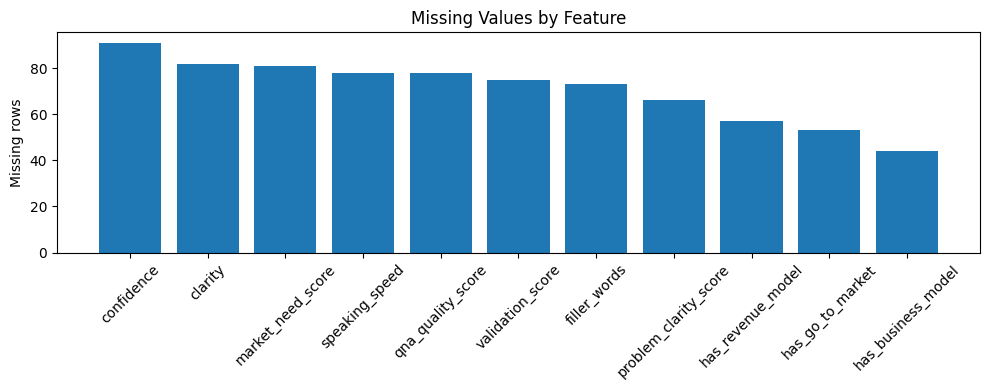

In [5]:
missing = data_with_issues.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing.index, missing.values, color="#1f77b4")
ax.set_title("Missing Values by Feature")
ax.set_ylabel("Missing rows")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


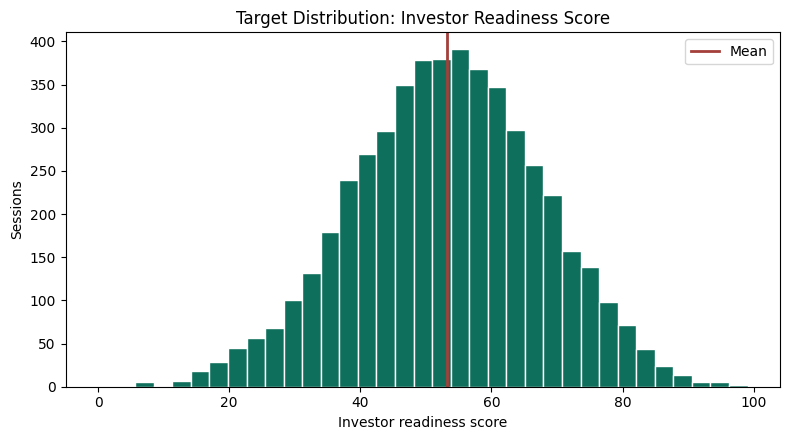

count    5000.00
mean       53.16
std        14.47
min         0.00
25%        43.45
50%        53.28
75%        63.16
max        99.07
Name: investor_readiness_score, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(data_with_issues["investor_readiness_score"], bins=35, color="#0e6f5c", edgecolor="white")
ax.axvline(data_with_issues["investor_readiness_score"].mean(), color="#a43f3a", linewidth=2, label="Mean")
ax.set_title("Target Distribution: Investor Readiness Score")
ax.set_xlabel("Investor readiness score")
ax.set_ylabel("Sessions")
ax.legend()
plt.tight_layout()
plt.show()

data_with_issues["investor_readiness_score"].describe().round(2)


## 5. EDA - Feature Distributions

These plots show whether the synthetic features look realistic for a founder pitch session: scores are in a 0-100 range, speaking speed is around a normal presentation pace, and filler words are skewed toward lower counts.


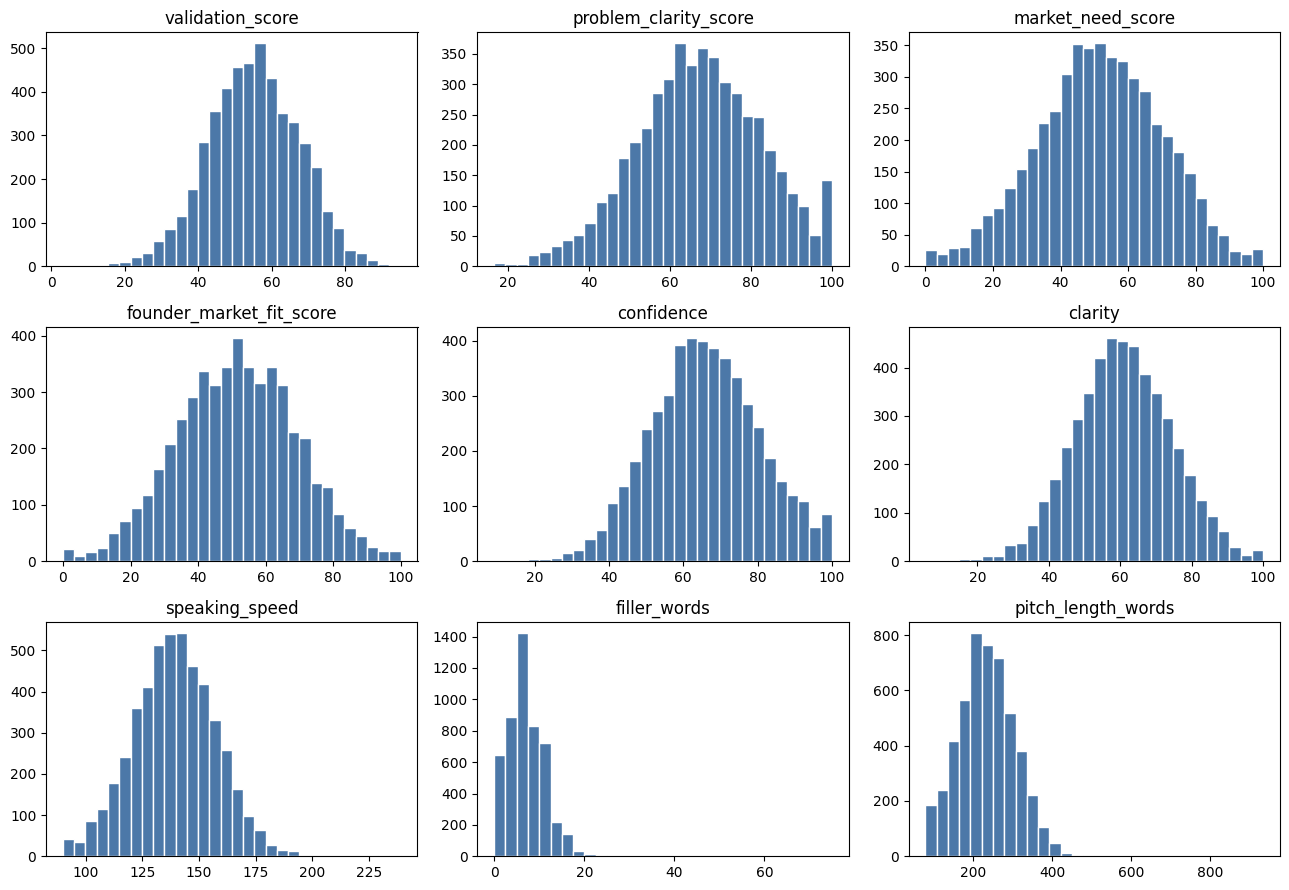

In [7]:
plot_columns = [
    "validation_score",
    "problem_clarity_score",
    "market_need_score",
    "founder_market_fit_score",
    "confidence",
    "clarity",
    "speaking_speed",
    "filler_words",
    "pitch_length_words",
]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, column in zip(axes.ravel(), plot_columns):
    ax.hist(data_with_issues[column].dropna(), bins=30, color="#4c78a8", edgecolor="white")
    ax.set_title(column)
plt.tight_layout()
plt.show()


## 6. EDA - Relationship Between Signals and Readiness

The model should learn intuitive relationships: stronger validation and clearer delivery should generally increase readiness, while too many filler words should hurt the score.


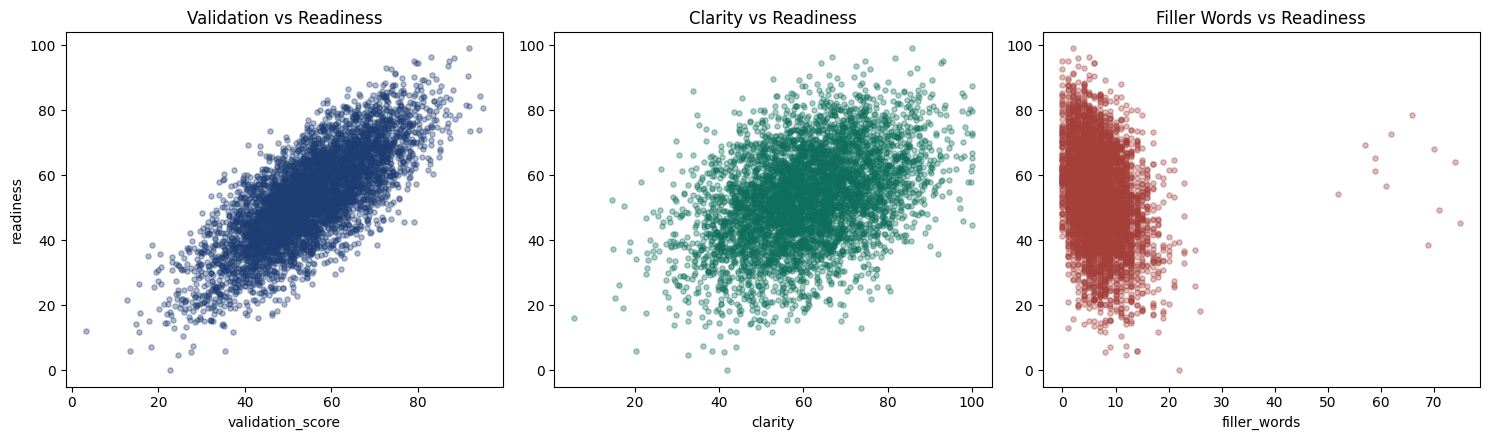

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(data_with_issues["validation_score"], data_with_issues["investor_readiness_score"], alpha=0.35, s=14, color="#1d3d73")
axes[0].set_title("Validation vs Readiness")
axes[0].set_xlabel("validation_score")
axes[0].set_ylabel("readiness")

axes[1].scatter(data_with_issues["clarity"], data_with_issues["investor_readiness_score"], alpha=0.35, s=14, color="#0e6f5c")
axes[1].set_title("Clarity vs Readiness")
axes[1].set_xlabel("clarity")

axes[2].scatter(data_with_issues["filler_words"], data_with_issues["investor_readiness_score"], alpha=0.35, s=14, color="#a43f3a")
axes[2].set_title("Filler Words vs Readiness")
axes[2].set_xlabel("filler_words")

plt.tight_layout()
plt.show()


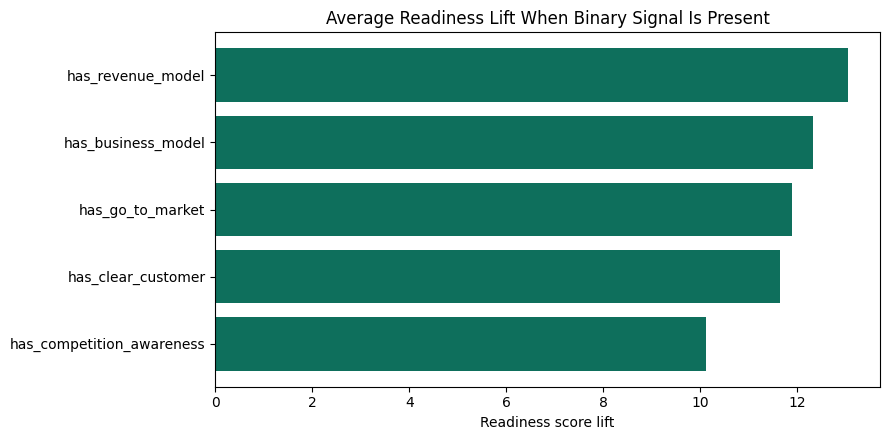

,feature,mean_if_0,mean_if_1,lift
2,has_competition_awareness,50.72,60.85,10.13
0,has_clear_customer,49.72,61.36,11.64
3,has_go_to_market,49.35,61.25,11.90
1,has_business_model,49.46,61.79,12.33
4,has_revenue_model,49.35,62.41,13.05


In [9]:
binary_columns = [
    "has_clear_customer",
    "has_business_model",
    "has_competition_awareness",
    "has_go_to_market",
    "has_revenue_model",
]

binary_impact = []
for column in binary_columns:
    grouped = data_with_issues.groupby(column, dropna=True)["investor_readiness_score"].mean()
    binary_impact.append(
        {
            "feature": column,
            "mean_if_0": grouped.get(0, np.nan),
            "mean_if_1": grouped.get(1, np.nan),
            "lift": grouped.get(1, np.nan) - grouped.get(0, np.nan),
        }
    )

binary_impact_df = pd.DataFrame(binary_impact).sort_values("lift", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(binary_impact_df["feature"], binary_impact_df["lift"], color="#0e6f5c")
ax.set_title("Average Readiness Lift When Binary Signal Is Present")
ax.set_xlabel("Readiness score lift")
plt.tight_layout()
plt.show()

binary_impact_df.round(2)


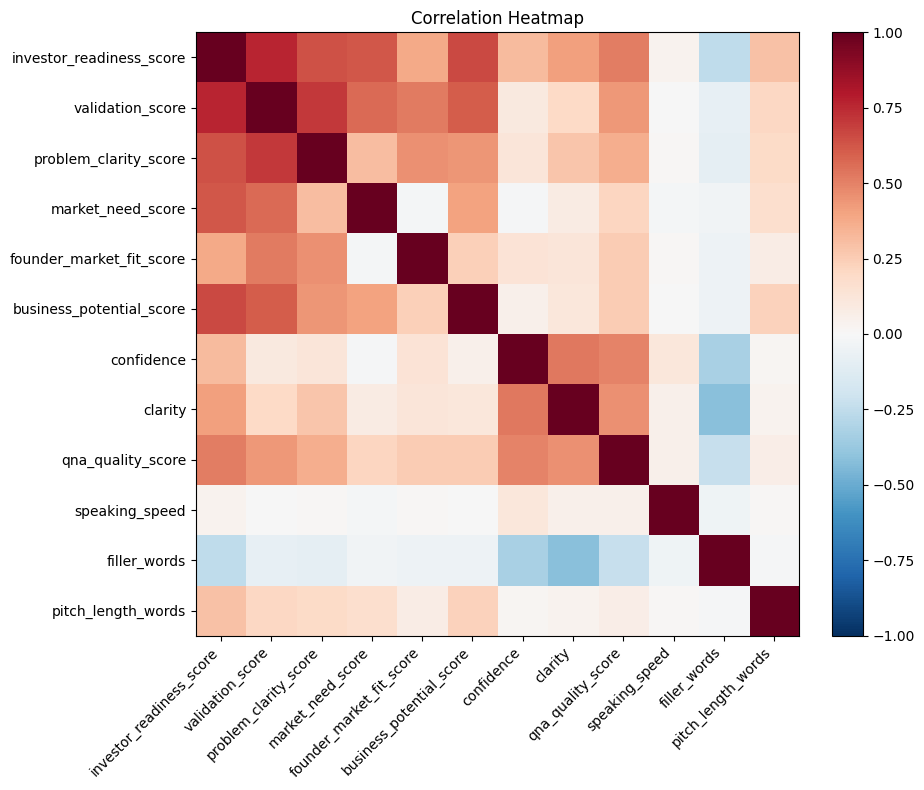

In [10]:
corr_columns = [
    "investor_readiness_score",
    "validation_score",
    "problem_clarity_score",
    "market_need_score",
    "founder_market_fit_score",
    "business_potential_score",
    "confidence",
    "clarity",
    "qna_quality_score",
    "speaking_speed",
    "filler_words",
    "pitch_length_words",
]

corr = data_with_issues[corr_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticklabels(corr_columns)
ax.set_title("Correlation Heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Feature Engineering and Preprocessing Plan

The backend feature list is the contract between training and inference. In this notebook, feature engineering has two layers:

1. **Signal design:** create meaningful founder/session features such as validation score, delivery metrics, Q&A quality, and business model flags.
2. **Model preprocessing:** clip impossible values and use a scikit-learn preprocessing pipeline for missing value imputation and scaling when needed.


In [11]:
feature_columns = get_feature_columns()
target_column = "investor_readiness_score"

score_columns = [
    "problem_clarity_score",
    "market_need_score",
    "founder_market_fit_score",
    "ai_fit_score",
    "business_potential_score",
    "validation_score",
    "confidence",
    "eye_contact",
    "clarity",
    "energy",
    "qna_quality_score",
]
binary_columns = [
    "has_clear_customer",
    "has_business_model",
    "has_competition_awareness",
    "has_go_to_market",
    "has_revenue_model",
]
numeric_columns = [column for column in feature_columns if column not in binary_columns]

modeling_data = data_with_issues.copy()
modeling_data[score_columns] = modeling_data[score_columns].clip(0, 100)
modeling_data["speaking_speed"] = modeling_data["speaking_speed"].clip(60, 220)
modeling_data["filler_words"] = modeling_data["filler_words"].clip(0, 80)
modeling_data["pitch_length_words"] = modeling_data["pitch_length_words"].clip(0, 1000)
modeling_data[binary_columns] = modeling_data[binary_columns].where(modeling_data[binary_columns].isna(), modeling_data[binary_columns].round().clip(0, 1))
modeling_data[target_column] = modeling_data[target_column].clip(0, 100)

modeling_data.to_csv(DATA_PATH, index=False)

print(f"Feature count: {len(feature_columns)}")
print(f"Numeric feature count: {len(numeric_columns)}")
print(f"Binary feature count: {len(binary_columns)}")
print(f"Training CSV saved to: {DATA_PATH}")
feature_columns


Feature count: 19
Numeric feature count: 14
Binary feature count: 5
Training CSV saved to: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts\synthetic_pitch_data.csv


['problem_clarity_score',
 'market_need_score',
 'founder_market_fit_score',
 'ai_fit_score',
 'business_potential_score',
 'validation_score',
 'confidence',
 'eye_contact',
 'speaking_speed',
 'filler_words',
 'clarity',
 'energy',
 'qna_quality_score',
 'pitch_length_words',
 'has_clear_customer',
 'has_business_model',
 'has_competition_awareness',
 'has_go_to_market',
 'has_revenue_model']

In [12]:
X = modeling_data[feature_columns]
y = modeling_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Missing values in X_train before pipeline preprocessing: {int(X_train.isna().sum().sum())}")


Training rows: 4,000
Test rows: 1,000
Missing values in X_train before pipeline preprocessing: 635


In [13]:
tree_preprocess = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_columns),
        ("binary", SimpleImputer(strategy="most_frequent"), binary_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

scaled_preprocess = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_columns),
        ("binary", SimpleImputer(strategy="most_frequent"), binary_columns),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessing pipelines created:")
print("- tree_preprocess: median/mode imputation")
print("- scaled_preprocess: imputation + scaling for linear baseline")


Preprocessing pipelines created:
- tree_preprocess: median/mode imputation
- scaled_preprocess: imputation + scaling for linear baseline


## 8. Model Selection

We compare a simple linear baseline with tree-based regressors. This gives a stronger story than training one model blindly: we test candidates, compare metrics, and only then choose the best model family.


In [14]:
candidate_models = {
    "Ridge Regression": Pipeline(
        steps=[
            ("preprocess", scaled_preprocess),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", RandomForestRegressor(n_estimators=140, random_state=RANDOM_STATE, n_jobs=1, min_samples_leaf=3)),
        ]
    ),
    "Extra Trees": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", ExtraTreesRegressor(n_estimators=140, random_state=RANDOM_STATE, n_jobs=1, min_samples_leaf=3)),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=180, max_depth=3, learning_rate=0.06)),
        ]
    ),
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_rows = []
for name, pipeline in candidate_models.items():
    cv = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    cv_rows.append(
        {
            "model": name,
            "cv_mae": -cv["test_mae"].mean(),
            "cv_rmse": -cv["test_rmse"].mean(),
            "cv_r2": cv["test_r2"].mean(),
            "fit_time_sec": cv["fit_time"].mean(),
        }
    )

model_selection = pd.DataFrame(cv_rows).sort_values("cv_r2", ascending=False).reset_index(drop=True)
model_selection.round(4)


,model,cv_mae,cv_rmse,cv_r2,fit_time_sec
0,Ridge Regression,4.2202,5.3238,0.8622,0.0191
1,Gradient Boosting,4.3244,5.3945,0.8586,2.2548
2,Extra Trees,4.5986,5.7754,0.8380,1.2281
3,Random Forest,4.9319,6.2132,0.8125,2.8642


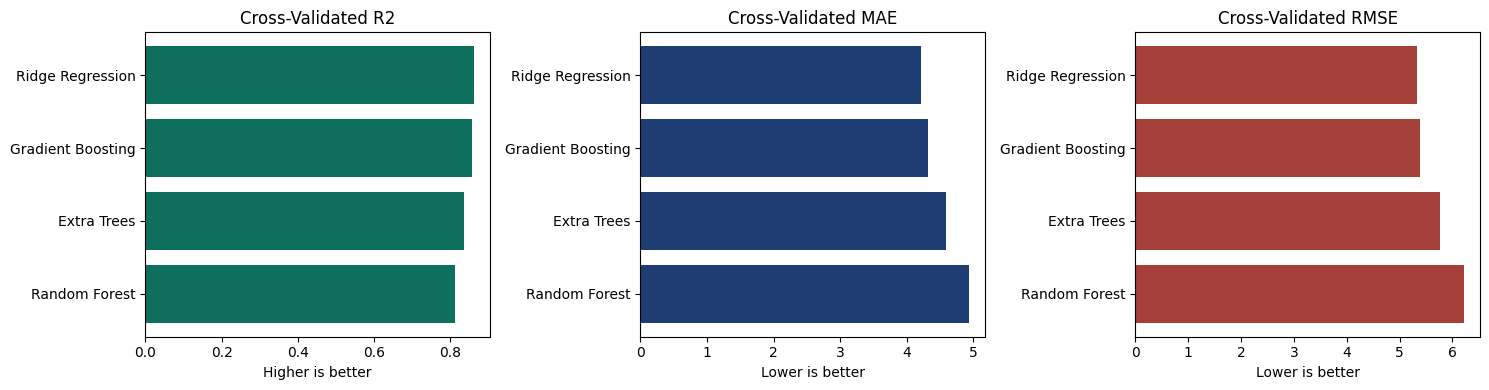

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = model_selection.sort_values("cv_r2", ascending=True)
axes[0].barh(plot_data["model"], plot_data["cv_r2"], color="#0e6f5c")
axes[0].set_title("Cross-Validated R2")
axes[0].set_xlabel("Higher is better")

plot_data = model_selection.sort_values("cv_mae", ascending=False)
axes[1].barh(plot_data["model"], plot_data["cv_mae"], color="#1d3d73")
axes[1].set_title("Cross-Validated MAE")
axes[1].set_xlabel("Lower is better")

plot_data = model_selection.sort_values("cv_rmse", ascending=False)
axes[2].barh(plot_data["model"], plot_data["cv_rmse"], color="#a43f3a")
axes[2].set_title("Cross-Validated RMSE")
axes[2].set_xlabel("Lower is better")

plt.tight_layout()
plt.show()


## 9. Fine Tune the Best Model Family

The best model family from cross-validation is selected, then we run a compact grid search. The grid is intentionally small so this remains easy to run during a demo while still showing real model tuning.


In [16]:
best_family = model_selection.iloc[0]["model"]
print(f"Best model family from CV: {best_family}")

if best_family == "Gradient Boosting":
    base_pipeline = Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ]
    )
    param_grid = {
        "model__n_estimators": [160, 220],
        "model__learning_rate": [0.04, 0.06, 0.08],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [2, 5],
    }
elif best_family == "Random Forest":
    base_pipeline = Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]
    )
    param_grid = {
        "model__n_estimators": [160, 240],
        "model__max_depth": [None, 10, 16],
        "model__min_samples_leaf": [2, 4],
    }
elif best_family == "Extra Trees":
    base_pipeline = Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]
    )
    param_grid = {
        "model__n_estimators": [160, 240],
        "model__max_depth": [None, 12, 18],
        "model__min_samples_leaf": [2, 4],
    }
else:
    base_pipeline = Pipeline(
        steps=[
            ("preprocess", scaled_preprocess),
            ("model", Ridge()),
        ]
    )
    param_grid = {"model__alpha": [0.1, 1.0, 5.0, 10.0]}

search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)

search.fit(X_train, y_train)
print(f"Best CV RMSE: {-search.best_score_:.3f}")
print("Best params:")
search.best_params_


Best model family from CV: Ridge Regression


Best CV RMSE: 5.324
Best params:


{'model__alpha': 5.0}

In [17]:
tuning_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
columns_to_show = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "mean_fit_time",
]
param_columns = [column for column in tuning_results.columns if column.startswith("param_")]

tuning_summary = tuning_results[columns_to_show + param_columns].copy()
tuning_summary["mean_test_rmse"] = -tuning_summary["mean_test_score"]
tuning_summary["mean_train_rmse"] = -tuning_summary["mean_train_score"]
tuning_summary.drop(columns=["mean_test_score", "mean_train_score"], inplace=True)
tuning_summary.head(10).round(4)


,rank_test_score,std_test_score,mean_fit_time,param_model__alpha,mean_test_rmse,mean_train_rmse
2,1,0.1501,0.0200,5.0,5.3238,5.2828
3,2,0.1497,0.0193,10.0,5.3238,5.2830
1,3,0.1504,0.0207,1.0,5.3238,5.2827
0,4,0.1505,0.0207,0.1,5.3239,5.2827


## 10. Final Test Evaluation

After model selection and tuning, we evaluate once on the held-out test set. This is the number we should talk about in the video because the test set was not used during tuning.


In [18]:
best_model = search.best_estimator_
test_predictions = best_model.predict(X_test)
test_predictions = np.clip(test_predictions, 0, 100)

final_metrics = {
    "mae": float(mean_absolute_error(y_test, test_predictions)),
    "rmse": float(np.sqrt(mean_squared_error(y_test, test_predictions))),
    "r2": float(r2_score(y_test, test_predictions)),
    "model_type": type(best_model.named_steps["model"]).__name__,
    "selected_model_family": best_family,
    "model_version": "synthetic_v1",
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(feature_columns)),
    "best_params": search.best_params_,
}

print(f"Final Test MAE: {final_metrics['mae']:.3f}")
print(f"Final Test RMSE: {final_metrics['rmse']:.3f}")
print(f"Final Test R2: {final_metrics['r2']:.3f}")
pd.DataFrame([final_metrics])


Final Test MAE: 4.279
Final Test RMSE: 5.397
Final Test R2: 0.869


,mae,rmse,r2,model_type,selected_model_family,model_version,training_rows,test_rows,feature_count,best_params
0,4.278772,5.397062,0.868853,Ridge,Ridge Regression,synthetic_v1,4000,1000,19,{'model__alpha': 5.0}


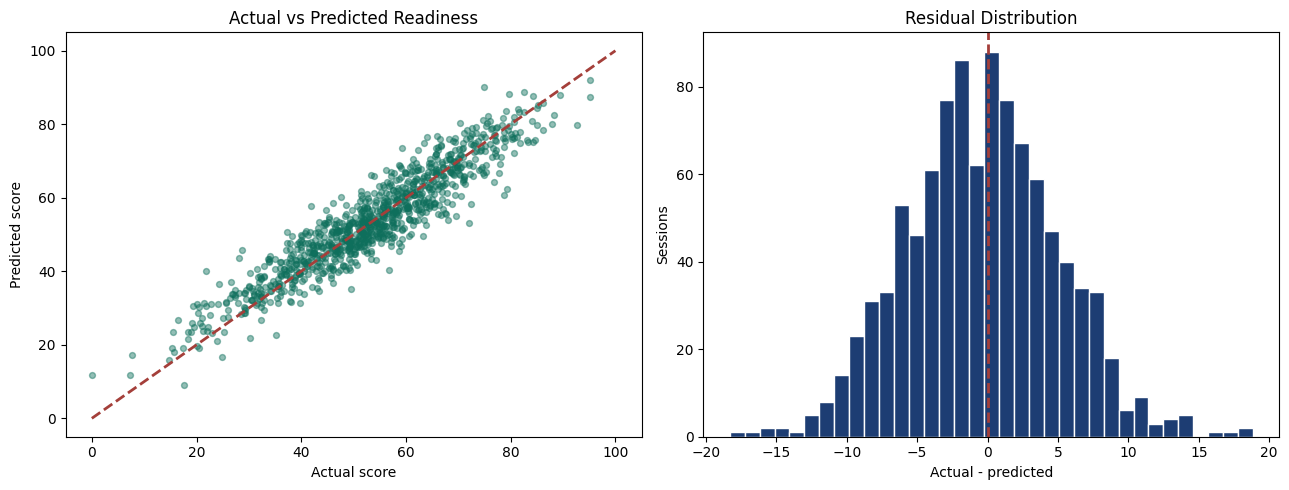

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, test_predictions, alpha=0.45, s=18, color="#0e6f5c")
axes[0].plot([0, 100], [0, 100], color="#a43f3a", linestyle="--", linewidth=2)
axes[0].set_title("Actual vs Predicted Readiness")
axes[0].set_xlabel("Actual score")
axes[0].set_ylabel("Predicted score")

residuals = y_test - test_predictions
axes[1].hist(residuals, bins=35, color="#1d3d73", edgecolor="white")
axes[1].axvline(0, color="#a43f3a", linestyle="--", linewidth=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - predicted")
axes[1].set_ylabel("Sessions")

plt.tight_layout()
plt.show()


## 11. Model Explainability: Top Signals

For the demo, feature importance helps explain why the model gives a readiness score. This is not a full causal explanation, but it gives a practical view of which signals the model uses most.


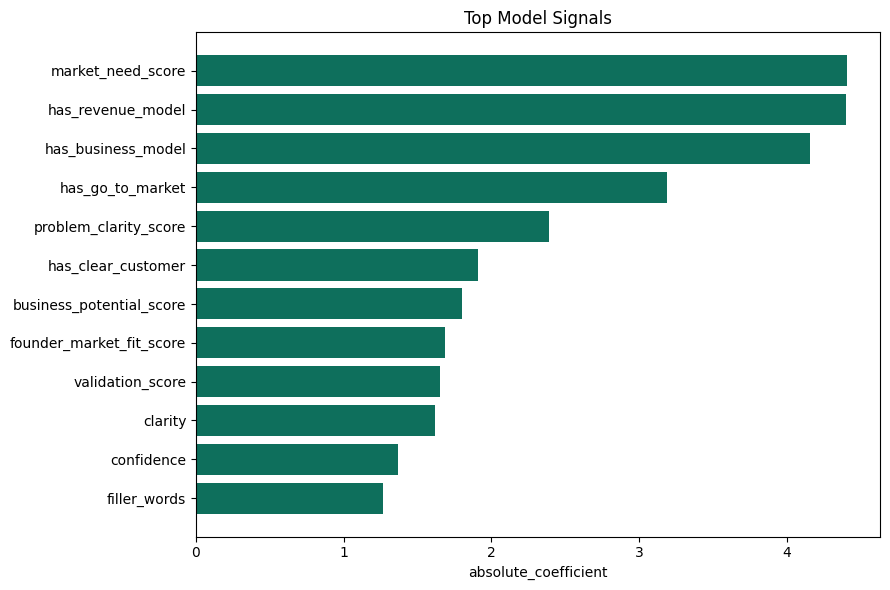

,feature,absolute_coefficient
1,market_need_score,4.4091
18,has_revenue_model,4.3990
15,has_business_model,4.1584
17,has_go_to_market,3.1891
0,problem_clarity_score,2.3860
14,has_clear_customer,1.9059
4,business_potential_score,1.7983
2,founder_market_fit_score,1.6887
5,validation_score,1.6524
10,clarity,1.6204


In [20]:
fitted_regressor = best_model.named_steps["model"]

if hasattr(fitted_regressor, "feature_importances_"):
    importance_values = fitted_regressor.feature_importances_
    importance_label = "importance"
elif hasattr(fitted_regressor, "coef_"):
    importance_values = np.abs(fitted_regressor.coef_)
    importance_label = "absolute_coefficient"
else:
    importance_values = np.zeros(len(feature_columns))
    importance_label = "importance"

importance = pd.DataFrame(
    {
        "feature": feature_columns,
        importance_label: importance_values,
    }
).sort_values(importance_label, ascending=False)

top_importance = importance.head(12).sort_values(importance_label, ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_importance["feature"], top_importance[importance_label], color="#0e6f5c")
ax.set_title("Top Model Signals")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.show()

importance.head(12).round(4)


## 12. Save Production Artifacts

The backend loads these files directly:

- `investor_readiness_model.joblib`
- `feature_columns.json`
- `model_metrics.json`
- `synthetic_pitch_data.csv`


In [21]:
joblib.dump(best_model, MODEL_PATH)
FEATURE_COLUMNS_PATH.write_text(json.dumps(feature_columns, indent=2), encoding="utf-8")
METRICS_PATH.write_text(json.dumps(final_metrics, indent=2), encoding="utf-8")

print(f"Model saved to: {MODEL_PATH}")
print(f"Feature columns saved to: {FEATURE_COLUMNS_PATH}")
print(f"Metrics saved to: {METRICS_PATH}")
print(f"Training data saved to: {DATA_PATH}")


Model saved to: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts\investor_readiness_model.joblib
Feature columns saved to: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts\feature_columns.json
Metrics saved to: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts\model_metrics.json
Training data saved to: C:\Users\user\Desktop\Immigrant-Hackathon-NYC\backend\artifacts\synthetic_pitch_data.csv


## 13. Backend-Style Prediction Smoke Test

This final test proves that the trained artifact can be loaded by the same model service used by FastAPI. This is the bridge between the ML notebook and the product flow.


In [22]:
from backend.ml.model_service import ReadinessModelService

sample_session_state = {
    "startup_idea": "AI pitch room for immigrant founders with subscription pricing and accelerator partnerships.",
    "target_customer": "immigrant founders, accelerator teams, and startup operators",
    "problem": "Founders need clearer investor storytelling, market validation, and confident Q&A before fundraising.",
    "transcript": "We help immigrant founders prepare investor pitches with validation, pricing, revenue model, go-to-market strategy, competition awareness, and investor Q&A practice.",
    "metrics": {
        "confidence": 84,
        "eye_contact": 82,
        "energy": 80,
    },
    "qna": [
        {
            "question": "Who pays?",
            "answer": "Accelerators and founders pay a subscription because the product improves pitch readiness and investor conversations.",
        }
    ],
}

service = ReadinessModelService()
prediction = service.predict_from_state(sample_session_state)
prediction


{'readiness_score': 80,
 'readiness_probability': 0.8,
 'risk_level': 'Low',
 'model_version': 'synthetic_v1',
 'score_source': 'ml_model',
 'top_signals': ['Business and revenue model are present']}

## 14. Demo Talking Points

In the video, the concise explanation is:

1. We do not have real historical investor outcomes yet, so we generate synthetic but realistic founder pitch/session data.
2. We inspect the data with EDA, check missingness, distributions, correlations, and signal relationships.
3. We preprocess data with clipping, imputation, and scaling where appropriate.
4. We compare several model families with cross-validation.
5. We fine tune the best model family with grid search.
6. We save the trained model artifact and load it from the backend.
7. The app uses the ML prediction as the final Investor Readiness Score while keeping a heuristic fallback for demo reliability.
